# Denver Water Quality Final Proj



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [2]:

data = '2024_Water_Quality.xlsx'
df = pd.read_excel(data)
df.head()


,SYS_LOC_CODE,LOC_NAME,SAMPLE_DATE,MATRIX_CODE,FRACTION,CAS_RN,CHEMICAL_NAME,REPORT_RESULT_VALUE,REPORT_RESULT_UNIT,REPORT_RESULT_LIMIT,VALIDATOR_QUALIFIERS,LAB_QUALIFIERS
0,BC21,Bear Creek - South Platte Confluence,2024-01-10 11:22:00,SW,D,7439-92-1,Lead,0.50,ug/L,0.50,NaN,U
1,BC21,Bear Creek - South Platte Confluence,2024-01-10 11:22:00,SW,D,7440-02-0,Nickel,2.00,ug/L,2.00,NaN,U
2,BC21,Bear Creek - South Platte Confluence,2024-01-10 11:22:00,SW,D,7440-50-8,Copper,2.00,ug/L,2.00,NaN,U
3,BC21,Bear Creek - South Platte Confluence,2024-01-10 11:22:00,SW,T,7439-97-6,Mercury,0.10,ug/L,0.10,NaN,U
4,BC21,Bear Creek - South Platte Confluence,2024-01-10 11:22:00,WS,T,14797-65-0,"Nitrogen, Nitrite",0.01,mg/L,0.01,NaN,<


In [3]:
df['SAMPLE_DATE'] = pd.to_datetime(df['SAMPLE_DATE'])

df['month'] = df['SAMPLE_DATE'].dt.month
df['month_name'] = df['SAMPLE_DATE'].dt.strftime('%b')
df['quarter'] = df['SAMPLE_DATE'].dt.quarter

def get_season(month):


    if month==12 or month ==1 or month ==2:
        return 'Winter'
    elif month == 3 or month == 4 or month ==5:
        return 'Spring'
    elif month== 6 or month==7 or month==8:
        return 'Summer'
    elif month== 9 or month==10 or month==11:
        return 'Fall'


df['season'] = df['month'].apply(get_season)
df['REPORT_RESULT_VALUE'] = pd.to_numeric(df['REPORT_RESULT_VALUE'], errors='coerce')

def WhichRiv(name):
    name_lower = name.lower()
    if 'south platte' in name_lower:  return 'South Platte River'
    if 'cherry creek'  in name_lower:  return 'Cherry Creek'
    if 'bear creek'    in name_lower:  return 'Bear Creek'
    if 'westerly'      in name_lower:  return 'Westerly Creek'
    return 'Gulch / Other'

df['waterbody'] = df['LOC_NAME'].apply(WhichRiv)

Question 1 Throughout each season, are there any noticeable changes to water quality?

This was my first question of the data set and I aim to answer this question by getting the medians of all the chemcials, metals, etc in all the rivers to see if there are any noticbale differnces per season and to see if there was a cause to each one


In [4]:
metals = ['Copper','Lead','Mercury', 'Nickel']
chemicals = ['Nitrogen, Nitrate',  'Nitrogen, Nitrite',
             'Phosphorus',  'Phosphorus, orthophosphate as P']
ecoli = ['E.Coli']
ph = ['pH']

In [5]:
seasono= ['Winter', 'Spring', 'Summer', 'Fall' ]
def plot_group(seasonal, df, chem_list, title, nrows, ncols):
    fig, axes =plt.subplots(nrows, ncols,figsize=(14, 5*nrows))
    axes =axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    for i, chem in enumerate(chem_list):
        ax =axes[i]
        sub=seasonal[seasonal['CHEMICAL_NAME'] == chem]

        unit =df.loc[df['CHEMICAL_NAME'] == chem, 'REPORT_RESULT_UNIT'].iloc[0]
        ax.bar(sub['season'], sub['REPORT_RESULT_VALUE'])
        ax.set_title(chem)
        ax.set_ylabel(f'Median ({unit})'  )
        maxv = sub['REPORT_RESULT_VALUE'].max()
        ax.set_ylim(0, maxv * 1.6)



##FIX THE SEASON ORDER OR ELSE BREAK
    for j in range(len(chem_list), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
  

seasonal=(


    df.groupby(['season', 'CHEMICAL_NAME'])['REPORT_RESULT_VALUE' ]
      .median()
      .reset_index()


)


seasonal['season'] =pd.Categorical(seasonal['season'], seasono, ordered=True)
seasonal = seasonal.sort_values('season')

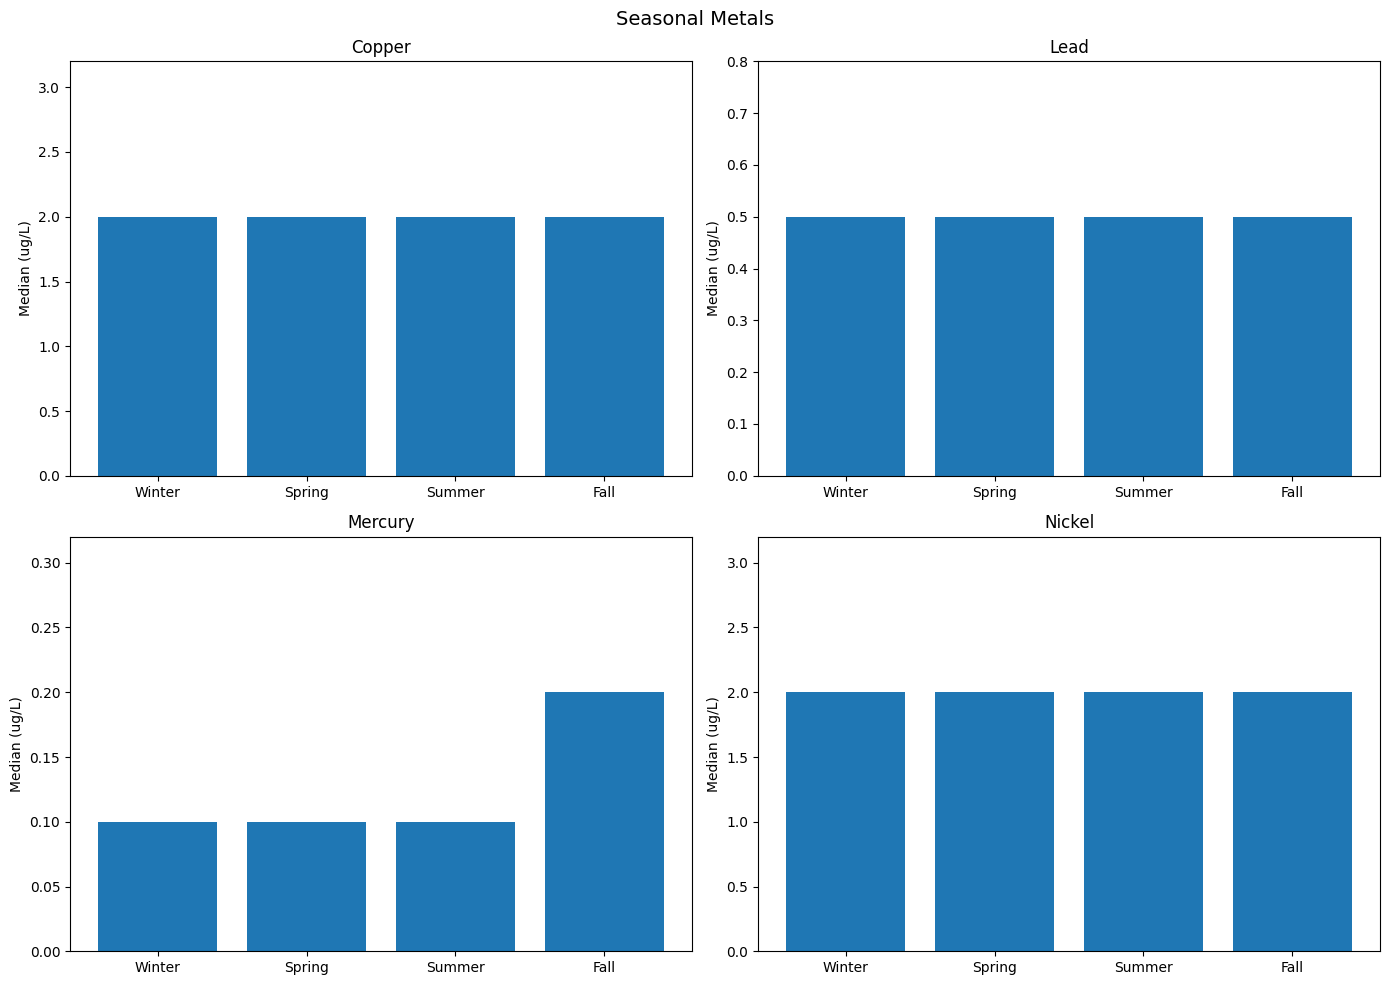

In [6]:
plot_group(seasonal,df, metals,'Seasonal Metals', 2, 2)

For metals you can see that almost all of these are even all which tells us two things. The first is that metal wise the water quality is quite good as for lead 0.5 ug/L is considered quite healthy for rivers, as it indicates no toxicity. At around 15 ug/L lead is considered a health risk so it being at 0,5 is extremely healthy. For nickel and copper it being around 2 ug/L is also quite good as it indicates no toxicity and that the water is passable for the surrounding ecology.




The only one for metal that is not standard throughout the seasons is mercury,with it being at a stable and safe 0.1 ug/L until it spiked in the fall to 0.2 ug/L, which is still safe but double what it was in previous seasons. While this may seem like a major concern, but it was due to things such as leaves dropping into the water and decomposing in them during the fall, which can lead to higher levels of mercury, however, it is not enough mercury to warrant any safety concerns as mercury is only considered unsafe at 2 ug/L or higher.


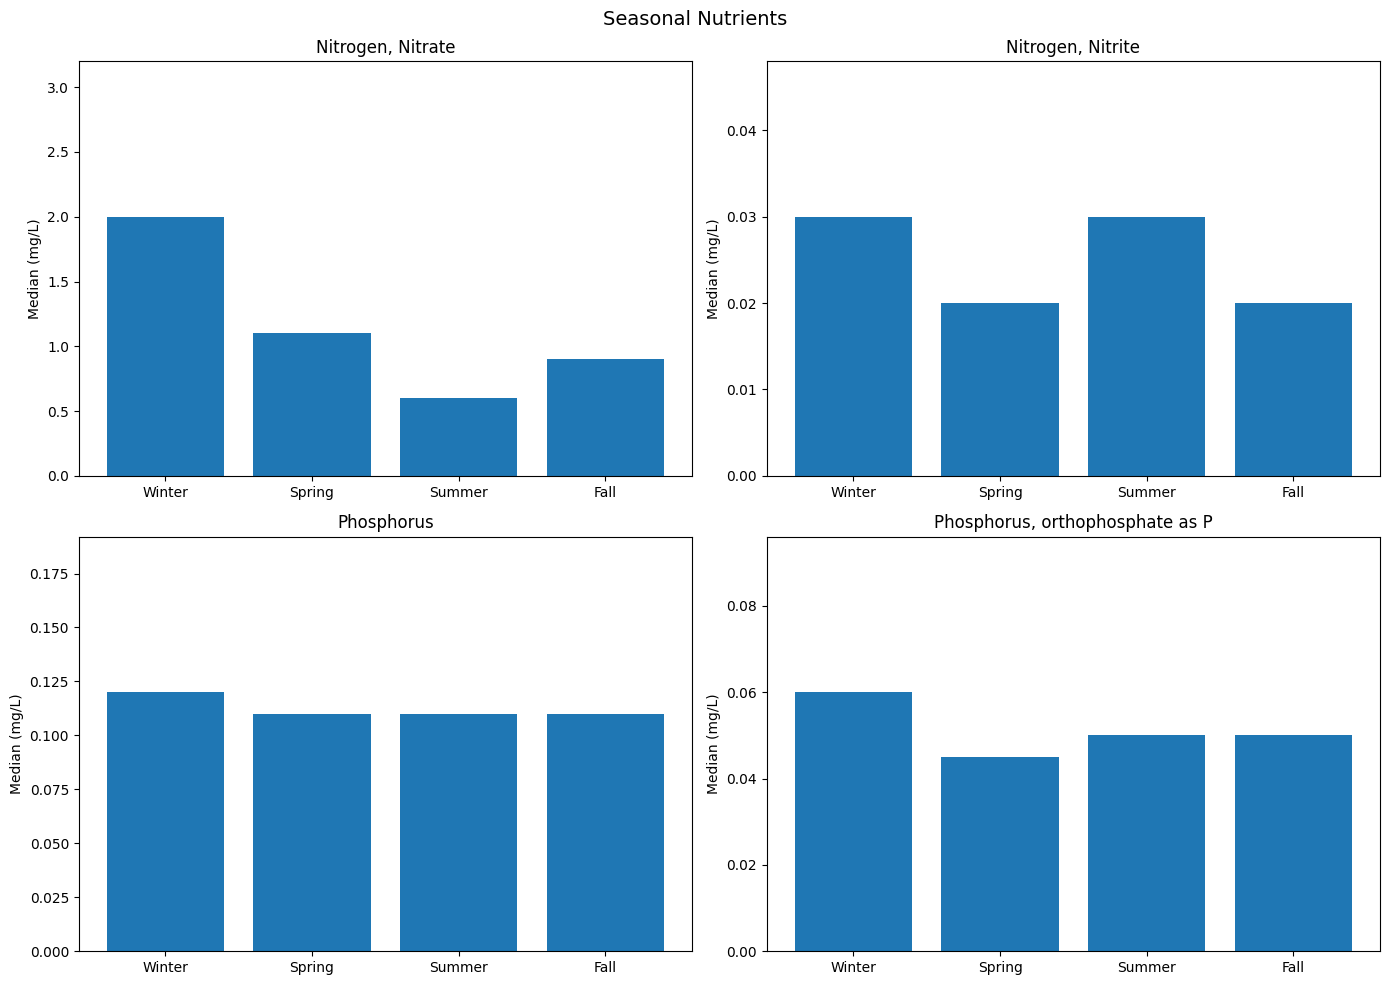

In [7]:
plot_group(seasonal, df, chemicals, 'Seasonal Nutrients',2,  2)

For both of the Phosphorus we can see that the amount remains very stable throughout the seasons and they are both under the 1 mg/L safety limit so there is no concern about water quality there.

For both Nitrate and Nitrite they both have ununsal peaks and they are not all even but they are all under the 1.65 mg/L which means water quality that their so no concerns about water quality from these chemicals.

The peak in winter for nitrate can be explained by the fact that most plants are not using nitrate to grow which means that there is more during this time.

The peak in Summer for nitrite is most likely due to fertizler run off which is why it peaks in the summer as thats when most farming is done. With the reasoning for winter being the same as nitrate



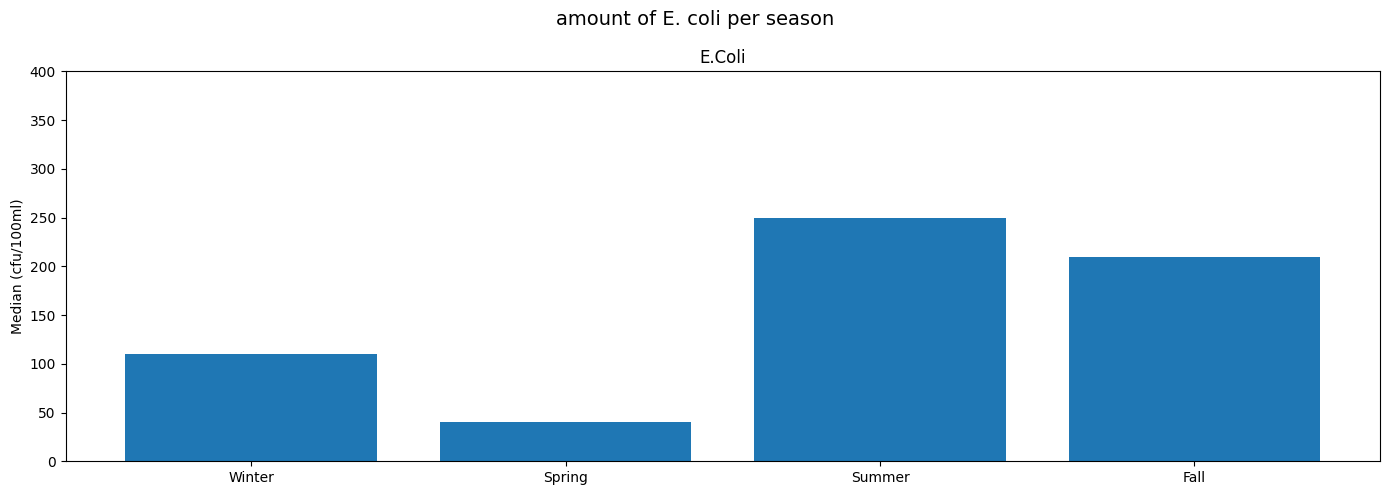

In [8]:
plot_group(seasonal, df, ecoli, 'amount of E. coli per season', 1, 1)

For E.coli the level considered safe for rivers is 26 CFU/100 mL or less; however forr this graph we can see that this is passed by a very large amount in all of the seasons with summer and fall being the highest due to it being warmer, which increases bacterial growth. Since this amount of E. coli is considered unsafe, I will focus on that for my next question, which is about water quality in different regions/bodies of water in the Denver area.

Question 2 Are there regions in Denver with noticeably worse water quality?



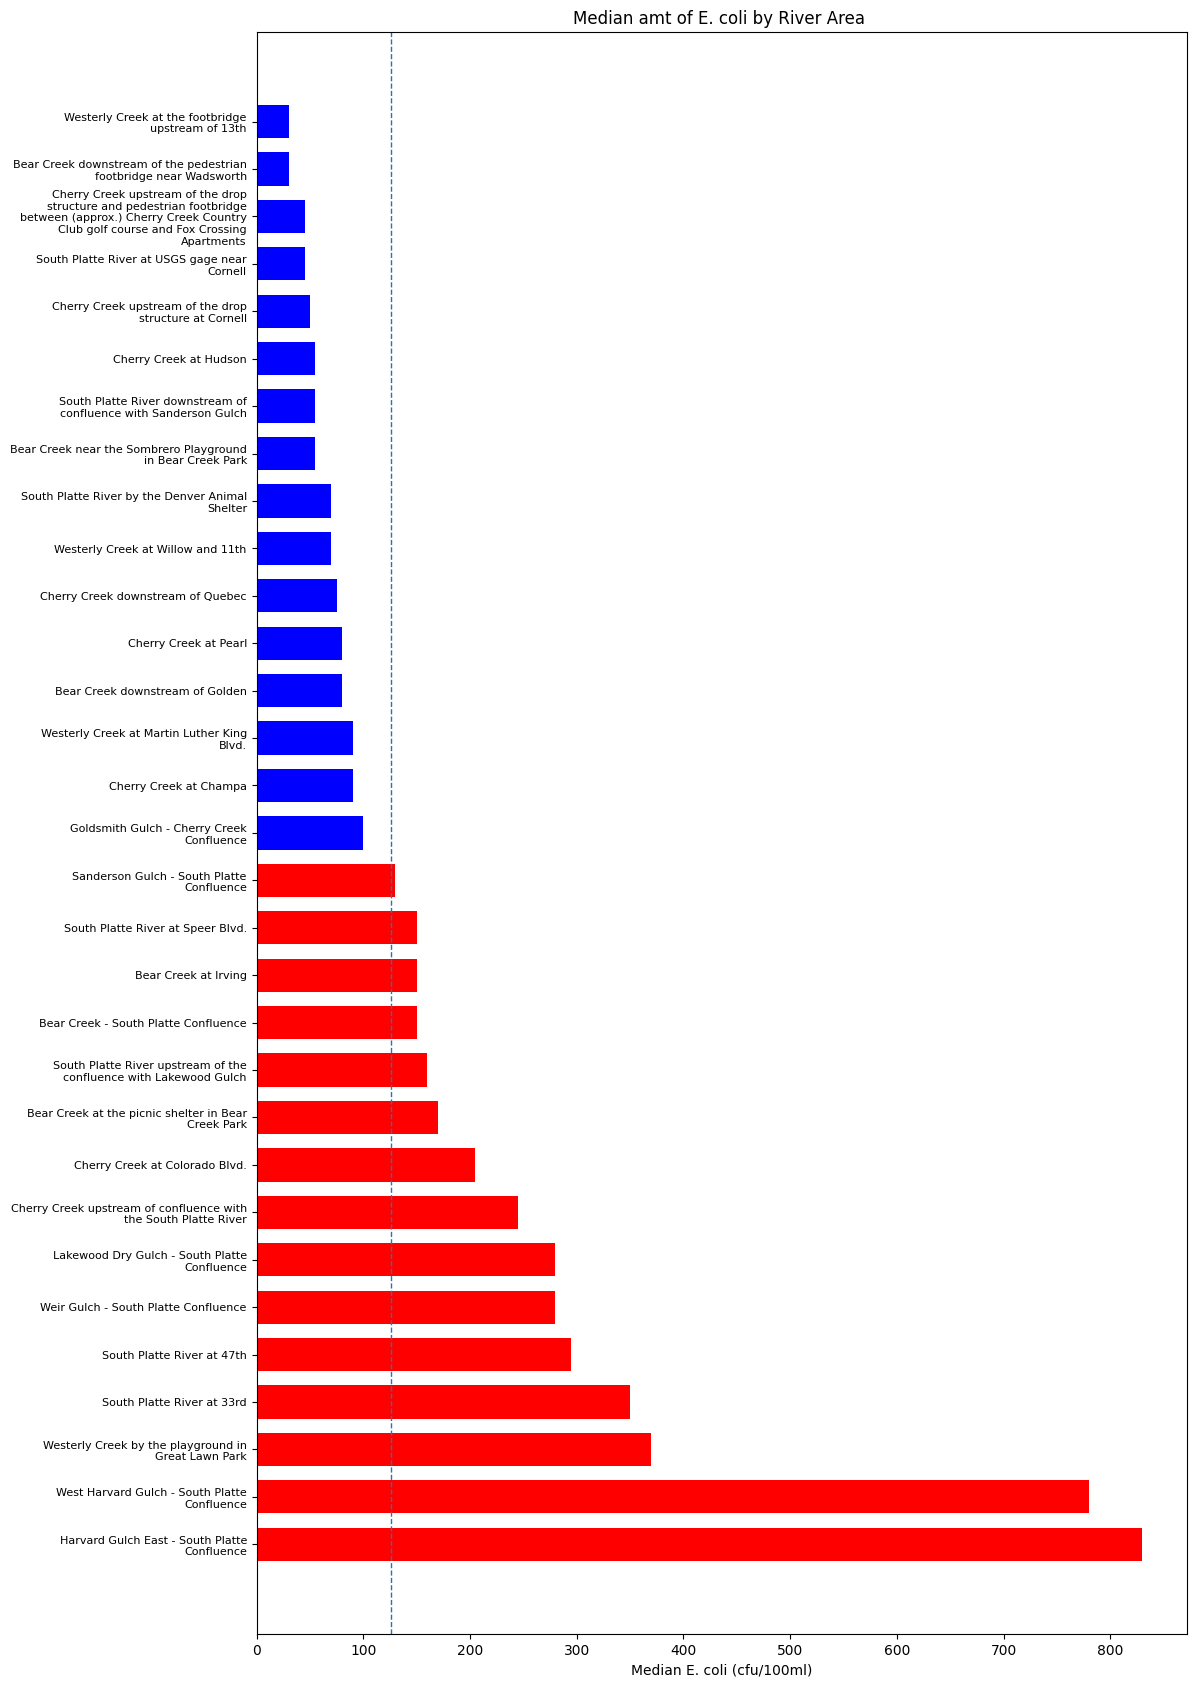

In [9]:
import textwrap
import numpy as np

ecoli=(
    df[df['CHEMICAL_NAME'] == 'E.Coli']
    .groupby('LOC_NAME')['REPORT_RESULT_VALUE']
    .median()
    .sort_values(ascending=False)
)


##make sure its readable, long names make it harder and if dont wrap causes read issues, major pain fix later
labels=['\n'.join(textwrap.wrap(l, 40)) for l in ecoli.index]
value=ecoli.values
lamt = [l.count('\n')+ 1 for l in labels]
fh = sum(lamt)*  0.4
fig, ax = plt.subplots(figsize=(12,  fh))
colors = ['red' if v >126 else 'blue' for v in value]
ax.barh(labels,value,color=colors, height=0.7)
ax.axvline(126, linestyle='--', linewidth=1)
ax.set_xlabel('Median E. coli (cfu/100ml)')
ax.set_title('Median amt of E. coli by River Area ')
ax.tick_params(axis='y',  labelsize=8)
plt.show()

With this graph we can now see a that there is a major difference in water quality based on the area/river. The blue line indicates the limit of E coli that is considered safe for water to swim and be in. While we can see that there are some areas of Bear and Cherry Creek that do have higher than recommended E. coli amounts, the river that has by far the most amount of E coli in the most places is the South Platte. This shows that South Platte river has an incredible amount of E coli in it which is extremely concerning.

Question 3 –Are there trends in the levels of specific chemicals or minerals across different water
sources in Denver?

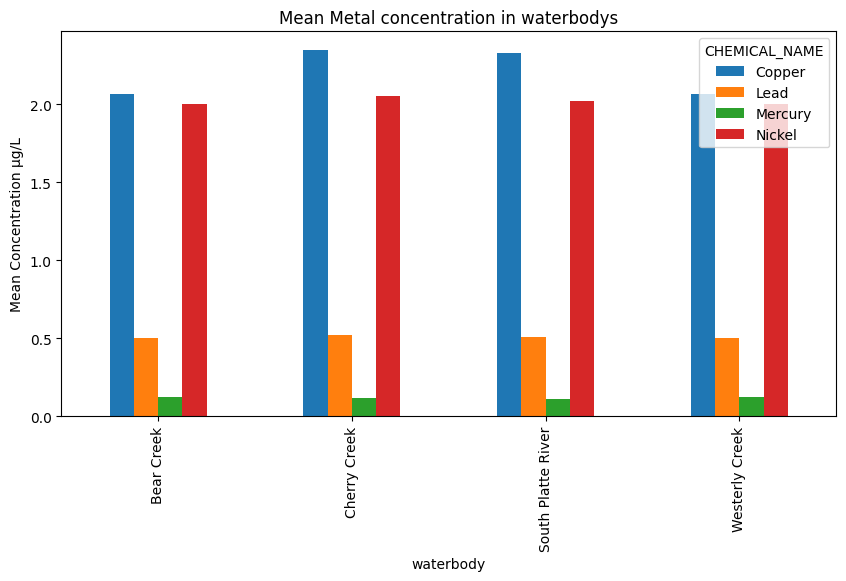

In [10]:
metal=['Lead', 'Nickel', 'Copper', 'Mercury']
metald= (
    df[df['CHEMICAL_NAME'].isin(metal)]
    .groupby(['waterbody', 'CHEMICAL_NAME'])['REPORT_RESULT_VALUE']
    .mean()
    .unstack()
)



fig, ax = plt.subplots(figsize=(10, 5))
metald.plot(kind='bar', ax=ax)
ax.set_ylabel('Mean Concentration μg/L')
ax.set_title('Mean Metal concentration in waterbodys')
plt.show()



Looking at this graph we can see that its pretty similar across the board for the concentration of metal in each river. This makes sense as since these Rivers are all near/in denver they have very similar sediment/rock patterns as they are all very close to each other.

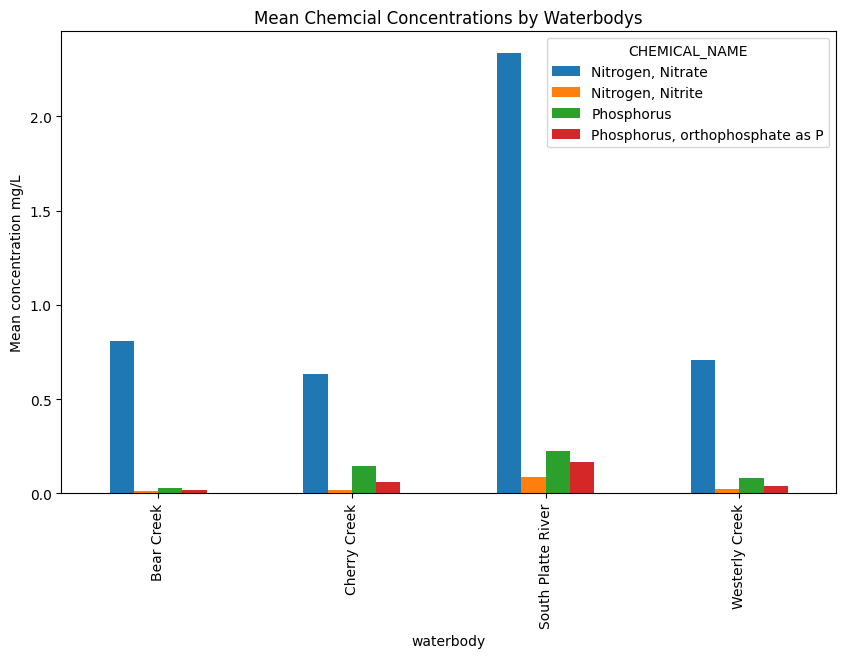

In [11]:
chem=['Nitrogen, Nitrate', 'Nitrogen, Nitrite',
             'Phosphorus', 'Phosphorus, orthophosphate as P']
chemd=(
    df[df['CHEMICAL_NAME'].isin(chem)]
    .groupby(['waterbody',  'CHEMICAL_NAME'])['REPORT_RESULT_VALUE']
    .mean()
    .unstack()

)





fig,ax = plt.subplots(figsize=(10, 6))
chemd.plot(kind='bar',ax=ax)
ax.set_ylabel('Mean concentration mg/L')
ax.set_title('Mean Chemcial Concentrations by Waterbodys')
plt.show()

For this graph, we can see that the South Platte River has an extremely high amount of nitrate in its river compared to the other 3 rivers. While the other chemicals also deviate a little bit per river, but, just like e coli, the South platte has an extremely high amount of nitrate in it, which could be because of many factors, one of which is discussed in the next question.

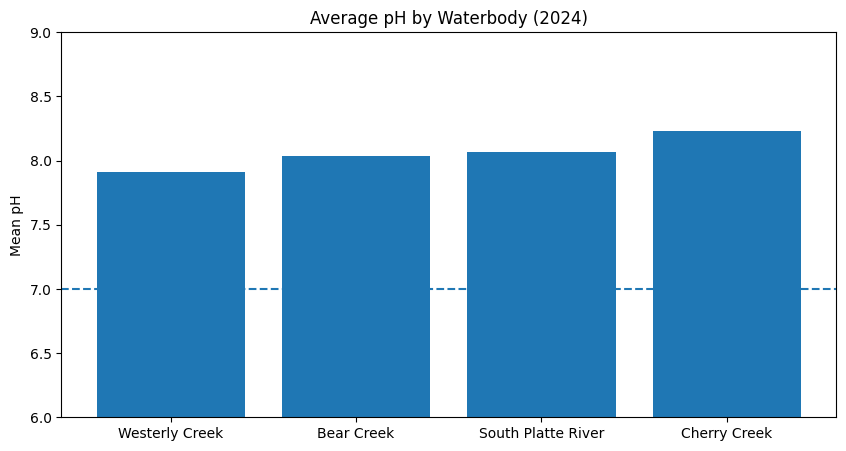

In [12]:
phd=(
    df[df['CHEMICAL_NAME'] == 'pH']
    .groupby('waterbody')['REPORT_RESULT_VALUE']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(phd.index, phd.values)
ax.axhline(7.0, linestyle='--',linewidth=1.5)
ax.set_ylabel('Mean pH')
ax.set_title('Average pH by Waterbody (2024)' )

ax.set_ylim(6, 9)
plt.show()

Looking at the pH of each waterbody, we can see that they are all relatively similar, there is no real trend in ph as if there was a PH to high or low the ecology inside and outside the river would suffer greatly. a PH of 6-9 is considered safe/healthy for rivers, and a pH of 7.0 is considered the most neutral.


Question 4 & Conclusion: Do water bodys that are closer to urban infrastructure have lower water quality?


Looking at all of these graphs, we can see that one waterbody out of all of them has had dangerous levels of certain bacteria and higher levels of chemicals than any other water body. That waterbody is the South Platte River. While all of these rivers are close to urban cities, South platte river is the closest to downtown Dever and it is closest to industry factories and plants. This combination has caused the South platte river to become polluted as Denver has had extremely rapid population growth in the past, and that has caused things such as sewage overflow (the most likley cause of the amount of e colio in the river) to be diverted in the river. Furthermore, most of the waterbodys that have a unsafe amount of e coli are the ones closest to urban areas/citys such as Cherry Creek river near Colorado Boulevard. Because of this I think it can be said that water bodys that are closer to urban infrastructure have lower water quality, at least in the Denver area, as most of the rivers close to urban infrastructure and cities have high amounts of E coli than water bodys that are further away.
